In [ ]:
 # For tips on running notebooks in Google Colab, see
# https://pytorch.org/tutorials/beginner/colab
%matplotlib inline

# Class 2 — From Building Blocks to Training Well

In **Class 1** we covered the PyTorch fundamentals end to end: **tensors**,
**datasets & dataloaders**, **transforms**, **building networks** (`nn.Module`,
layers), **autograd**, **the optimization loop**, and **saving/loading**.

This notebook builds *forward* from there. We will:

1. **Recap** the essentials in one screen (no re-teaching).
2. **Train a model from scratch** — using the tensors + autograd you already
   know — to make the four-step training loop concrete.
3. Revisit the **FashionMNIST classifier** as a working base.
4. Go deeper into the things that decide whether training actually *works*:
   **activation functions**, **optimizers & learning rate**, and
   **overfitting & regularization**.

### One-screen recap from Class 1

| Concept | Key API | One-liner |
|---|---|---|
| Create tensor | `torch.tensor`, `torch.rand`, `torch.zeros` | n-dimensional array |
| Shape / dtype / device | `.shape`, `.dtype`, `.device` | what & where it is |
| Reshape | `.view`, `.reshape`, `.flatten` | change shape, not data |
| Math | `+ * @`, `.sum()`, `.mean()` | element-wise & matmul |
| GPU | `.to(device)` | move tensor to accelerator |
| NumPy bridge | `.numpy()`, `torch.from_numpy()` | shared memory (CPU) |
| Track gradients | `requires_grad=True` | record ops in a graph |
| Compute gradients | `loss.backward()` → `.grad` | reverse-mode autodiff |
| No gradients | `with torch.no_grad():` | inference / updates |

A 30-second warm-up to confirm everyone's runtime is alive:

In [ ]:
import torch

# Tensor recap
x = torch.arange(6.).reshape(2, 3)
print("x =\n", x, "\nshape:", tuple(x.shape), "| dtype:", x.dtype)

# Autograd recap: gradient of  L = sum(x @ w)  w.r.t. w
w = torch.randn(3, 1, requires_grad=True)
L = (x @ w).sum()
L.backward()
print("\ndL/dw =\n", w.grad)          # should equal column sums of x

x =
 tensor([[0., 1., 2.],
        [3., 4., 5.]]) 
shape: (2, 3) | dtype: torch.float32

dL/dw =
 tensor([[3.],
        [5.],
        [7.]])


--------------

## 1. Train a model *from scratch*

In Class 1 we saw how autograd computes gradients, but we never used them to
actually **train** anything. Let's close that gap with the simplest possible
model: fit a straight line `y = w·x + b` to noisy data using plain gradient
descent.

This tiny loop is the skeleton of *all* deep-learning training:

> **forward → loss → backward → update → repeat**

Everything later (and everything in Class 1's optimization section) just
automates these four steps.

In [ ]:
import matplotlib.pyplot as plt

torch.manual_seed(0)

# --- Synthetic data: true line is y = 2x + 1, plus a little noise ---
X = torch.linspace(-3, 3, 100).reshape(-1, 1)
y = 2 * X + 1 + 0.5 * torch.randn(X.shape)

# --- Parameters we want to learn (start them at zero) ---
w = torch.zeros(1, 1, requires_grad=True)
b = torch.zeros(1,    requires_grad=True)

lr = 0.05          # learning rate
epochs = 100

for epoch in range(epochs):
    # 1) Forward pass: prediction
    y_pred = X @ w + b

    # 2) Loss: mean squared error
    loss = ((y_pred - y) ** 2).mean()

    # 3) Backward pass: compute gradients dL/dw, dL/db
    loss.backward()

    # 4) Update parameters (manual SGD). Wrap in no_grad so the update
    #    itself is not tracked by autograd.
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

        # Reset gradients to zero for the next iteration (they accumulate!)
        w.grad.zero_()
        b.grad.zero_()

    if (epoch + 1) % 20 == 0:
        print(f"epoch {epoch+1:3d} | loss {loss.item():.4f} "
              f"| w {w.item():.3f} | b {b.item():.3f}")

print(f"\nLearned:  y = {w.item():.3f} x + {b.item():.3f}   (true: y = 2x + 1)")

epoch  20 | loss 0.2813 | w 1.998 | b 0.895
epoch  40 | loss 0.2626 | w 2.000 | b 1.004
epoch  60 | loss 0.2624 | w 2.000 | b 1.017
epoch  80 | loss 0.2624 | w 2.000 | b 1.018
epoch 100 | loss 0.2624 | w 2.000 | b 1.019

Learned:  y = 2.000 x + 1.019   (true: y = 2x + 1)


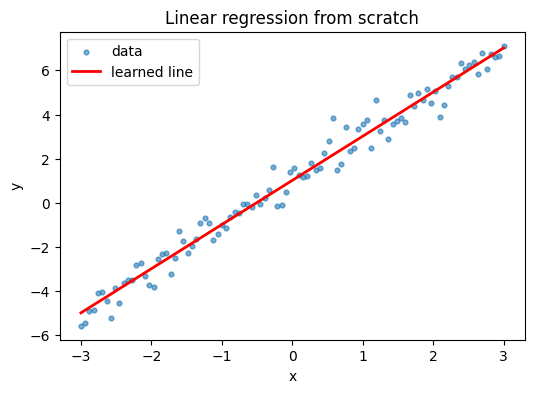

In [ ]:
# Visualize the fitted line against the data
with torch.no_grad():
    fitted = X @ w + b

plt.figure(figsize=(6, 4))
plt.scatter(X.numpy(), y.numpy(), s=12, alpha=0.6, label="data")
plt.plot(X.numpy(), fitted.numpy(), color="red", linewidth=2, label="learned line")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("Linear regression from scratch")
plt.show()

### From hand-written loops to the real API

Notice the four steps above:

| Step (from scratch) | What does it for us later |
|---|---|
| Define `w`, `b` by hand | `nn.Linear`, `nn.Module` |
| `loss = ((y_pred - y)**2).mean()` | `nn.CrossEntropyLoss`, `nn.MSELoss`, ... |
| `w -= lr * w.grad` | `torch.optim.SGD`, `Adam`, ... (`optimizer.step()`) |
| `w.grad.zero_()` | `optimizer.zero_grad()` |

The rest of this notebook is the **Quickstart**: the same four steps, but on a
real image-classification task, using these high-level building blocks.

--------------

--------------

## 2. A complete classifier (working base)

You walked through this full pipeline in **Class 1**, so treat it as a quick
refresher. We keep it here because the rest of today's notebook
(activations, optimizers, regularization) experiments directly on this model
and data.

### Working with data
PyTorch has two data primitives: ``torch.utils.data.DataLoader`` and
``torch.utils.data.Dataset``. ``Dataset`` stores the samples and their labels;
``DataLoader`` wraps an iterable around the ``Dataset`` with batching, shuffling
and parallel loading.

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

PyTorch offers domain-specific libraries such as [TorchText](https://pytorch.org/text/stable/index.html),
[TorchVision](https://pytorch.org/vision/stable/index.html), and [TorchAudio](https://pytorch.org/audio/stable/index.html),
all of which include datasets. For this tutorial, we  will be using a TorchVision dataset.

The ``torchvision.datasets`` module contains ``Dataset`` objects for many real-world vision data like
CIFAR, COCO ([full list here](https://pytorch.org/vision/stable/datasets.html)). In this tutorial, we
use the FashionMNIST dataset. Every TorchVision ``Dataset`` includes two arguments: ``transform`` and
``target_transform`` to modify the samples and labels respectively.



In [ ]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.95MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.14MB/s]


### Let's look at the data

Before modelling, it's good practice to actually *see* the data. FashionMNIST
contains 28x28 grayscale images across 10 clothing categories. Each item is a
`(image, label)` pair, where the image is a tensor of shape `[1, 28, 28]`.

Training samples: 60000 | Test samples: 10000
Single image shape: torch.Size([1, 28, 28]) | label: 9 (Ankle Boot)


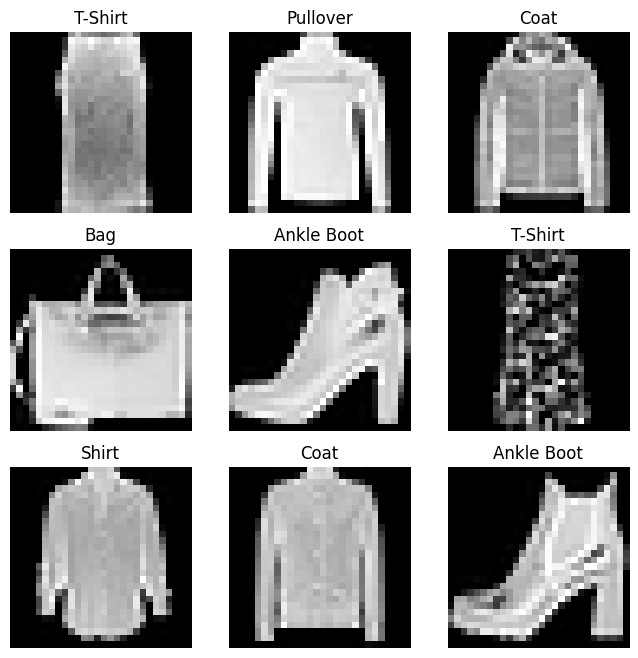

In [ ]:
import matplotlib.pyplot as plt

labels_map = {
    0: "T-Shirt", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
    5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot",
}

print(f"Training samples: {len(training_data)} | Test samples: {len(test_data)}")
img0, label0 = training_data[0]
print(f"Single image shape: {img0.shape} | label: {label0} ({labels_map[label0]})")

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

We pass the ``Dataset`` as an argument to ``DataLoader``. This wraps an iterable over our dataset, and supports
automatic batching, sampling, shuffling and multiprocess data loading. Here we define a batch size of 64, i.e. each element
in the dataloader iterable will return a batch of 64 features and labels.



In [ ]:
batch_size = 16

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([16, 1, 28, 28])
Shape of y: torch.Size([16]) torch.int64


Read more about [loading data in PyTorch](data_tutorial.html).




--------------




## Creating Models
To define a neural network in PyTorch, we create a class that inherits
from [nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html). We define the layers of the network
in the ``__init__`` function and specify how data will pass through the network in the ``forward`` function. To accelerate
operations in the neural network, we move it to the GPU or MPS if available.



In [ ]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        # self.linear_relu_stack = nn.Sequential(
        #     nn.Linear(28*28, 512),
        #     nn.ReLU(),
        #     nn.Linear(512, 512),
        #     nn.ReLU(),
        #     nn.Linear(512, 10)
        # )
        self.fc1 = nn.Linear(28*28, 512)
        self.r1 = nn.ReLU()
        self.fc2 =nn.Linear(512, 512)
        self.r2 = nn.ReLU()
        self.fc2_ =nn.Linear(512, 512)
        self.r2_ = nn.ReLU()
        self.fc3 = nn.Linear(512, 10)

    def forward(self, x):
        # print(x.shape)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.r1(x)
        x = self.fc2(x)
        x = self.r2(x)
        x = self.fc2_(x)
        x = self.r2_(x)
        logits = self.fc3(x)
        # logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

Using cuda device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (r1): ReLU()
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (r2): ReLU()
  (fc2_): Linear(in_features=512, out_features=512, bias=True)
  (r2_): ReLU()
  (fc3): Linear(in_features=512, out_features=10, bias=True)
)


Read more about [building neural networks in PyTorch](buildmodel_tutorial.html).




--------------




## Optimizing the Model Parameters
To train a model, we need a [loss function](https://pytorch.org/docs/stable/nn.html#loss-functions)
and an [optimizer](https://pytorch.org/docs/stable/optim.html).



In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In a single training loop, the model makes predictions on the training dataset (fed to it in batches), and
backpropagates the prediction error to adjust the model's parameters.



In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

We also check the model's performance against the test dataset to ensure it is learning.



In [ ]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

The training process is conducted over several iterations (*epochs*). During each epoch, the model learns
parameters to make better predictions. We print the model's accuracy and loss at each epoch; we'd like to see the
accuracy increase and the loss decrease with every epoch.



In [ ]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.311611  [   16/60000]
loss: 2.295466  [ 1616/60000]
loss: 2.293217  [ 3216/60000]
loss: 2.298220  [ 4816/60000]
loss: 2.288175  [ 6416/60000]
loss: 2.283366  [ 8016/60000]
loss: 2.272433  [ 9616/60000]
loss: 2.271176  [11216/60000]
loss: 2.280800  [12816/60000]
loss: 2.276723  [14416/60000]
loss: 2.268743  [16016/60000]
loss: 2.248243  [17616/60000]
loss: 2.267785  [19216/60000]
loss: 2.258022  [20816/60000]
loss: 2.253102  [22416/60000]
loss: 2.240945  [24016/60000]
loss: 2.244975  [25616/60000]
loss: 2.246921  [27216/60000]
loss: 2.223478  [28816/60000]
loss: 2.219954  [30416/60000]
loss: 2.212011  [32016/60000]
loss: 2.208085  [33616/60000]
loss: 2.167501  [35216/60000]
loss: 2.198174  [36816/60000]
loss: 2.252193  [38416/60000]
loss: 2.179503  [40016/60000]
loss: 2.137688  [41616/60000]
loss: 2.172347  [43216/60000]
loss: 2.105470  [44816/60000]
loss: 2.158373  [46416/60000]
loss: 2.153213  [48016/60000]
loss: 2.030660  [49616/60000]


Read more about [Training your model](optimization_tutorial.html).




--------------




## Saving Models
A common way to save a model is to serialize the internal state dictionary (containing the model parameters).



In [ ]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


## Loading Models

The process for loading a model includes re-creating the model structure and loading
the state dictionary into it.



In [ ]:
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

This model can now be used to make predictions.



In [ ]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()
x, y = test_data[0][0], test_data[0][1]
with torch.no_grad():
    x = x.to(device)
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')

Predicted: "Ankle boot", Actual: "Ankle boot"


--------------

## 3. Activation functions

Class 1 used `nn.ReLU` and `nn.Softmax` without dwelling on *why*. Activation
functions add the **non-linearity** that lets a network learn complex patterns.
Without them, stacking layers is pointless — a stack of linear layers collapses
into a single linear layer. Let's prove that, then look at the common choices.

In [ ]:
import torch
from torch import nn

# Why non-linearity matters: two linear layers with NO activation in between
# are mathematically equivalent to ONE linear layer.
torch.manual_seed(0)
lin1 = nn.Linear(4, 8, bias=False)
lin2 = nn.Linear(8, 2, bias=False)

x = torch.randn(1, 4)
two_layers = lin2(lin1(x))                 # stacked linear layers
equiv_W    = lin2.weight @ lin1.weight     # collapse into one matrix
one_layer  = x @ equiv_W.T

print("Two linear layers   :", two_layers.detach().numpy())
print("One equivalent layer:", one_layer.detach().numpy())
print("=> identical, so without activations depth buys us nothing.")

Two linear layers   : [[-0.43023524 -0.27259713]]
One equivalent layer: [[-0.43023524 -0.2725972 ]]
=> identical, so without activations depth buys us nothing.


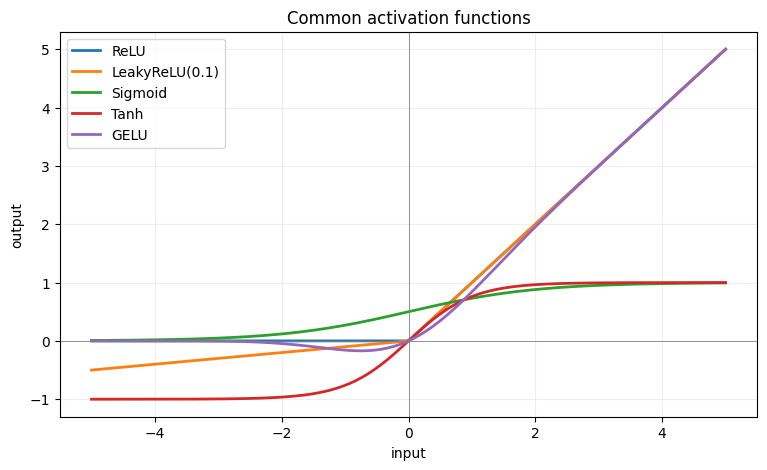

In [ ]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

z = torch.linspace(-5, 5, 200)
activations = {
    "ReLU":          torch.relu(z),
    "LeakyReLU(0.1)": F.leaky_relu(z, 0.1),
    "Sigmoid":       torch.sigmoid(z),
    "Tanh":          torch.tanh(z),
    "GELU":          F.gelu(z),
}

plt.figure(figsize=(9, 5))
for name, y in activations.items():
    plt.plot(z.numpy(), y.numpy(), label=name, linewidth=2)
plt.axhline(0, color="gray", lw=0.6); plt.axvline(0, color="gray", lw=0.6)
plt.title("Common activation functions"); plt.xlabel("input"); plt.ylabel("output")
plt.legend(); plt.grid(alpha=0.2); plt.show()

**Rules of thumb**

- **ReLU** — the default for hidden layers: cheap and avoids saturation for
  positive inputs. Its weakness is "dead" neurons (zero gradient when input < 0).
- **LeakyReLU / GELU** — variants that keep a small gradient for negative inputs;
  GELU is common in Transformers.
- **Sigmoid / Tanh** — squash to (0,1) / (−1,1). They **saturate** at the
  extremes, where gradients vanish, so they're rarely used in deep hidden layers
  today (sigmoid still appears in binary-classification outputs).
- **Softmax** — turns logits into a probability distribution for the **output**
  of a multi-class classifier (it's folded inside `nn.CrossEntropyLoss`, which is
  why our model returns raw logits).

--------------

## 4. Optimizers and the learning rate

Class 1 trained with `torch.optim.SGD`. The optimizer decides *how* to turn
gradients into parameter updates, and the **learning rate** is usually the single
most important hyperparameter. Let's compare a few optimizers — and a few
learning rates — on our linear-regression problem so the differences are visible.

## Mathematical Details of Optimizers

Optimizers are algorithms used to change the attributes of your neural network, such as weights and learning rate, to reduce the losses. The notebook discusses three main optimizers: Stochastic Gradient Descent (SGD), SGD with Momentum, and Adam.

### 1. Stochastic Gradient Descent (SGD)

SGD is an iterative method for optimizing an objective function with suitable smoothness properties (e.g., differentiable or subdifferentiable). It updates the model parameters in the opposite direction of the gradient of the objective function with respect to the parameters. Unlike batch gradient descent, SGD calculates the gradient using only a single training example or a small batch of examples, which makes it much faster for large datasets.

The update rule for SGD for a parameter $\theta$ is:

$$\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)$$

Where:
- $\theta_t$: Parameters at time step $t$
- $\eta$: Learning rate (a hyperparameter that determines the step size)
- $\nabla L(\theta_t)$: Gradient of the loss function $L$ with respect to parameters $\theta$ at time step $t$, computed on a mini-batch.

### 2. SGD with Momentum

SGD with Momentum is an extension to SGD that helps accelerate SGD in the relevant direction and dampens oscillations. It does this by adding a fraction of the update vector of the past time step to the current update vector.

The update rules for SGD with Momentum are:

$$v_{t+1} = \mu v_t - \eta \nabla L(\theta_t)$$
$$\theta_{t+1} = \theta_t + v_{t+1}$$

Where:
- $v_t$: Velocity vector at time step $t$, representing the accumulated gradients.
- $\mu$: Momentum coefficient (typically set to 0.9), which determines how much of the previous velocity is retained.
- $\eta$: Learning rate.
- $\nabla L(\theta_t)$: Gradient of the loss function.

### 3. Adam (Adaptive Moment Estimation)

Adam is an adaptive learning rate optimization algorithm that computes adaptive learning rates for each parameter. It stores an exponentially decaying average of past gradients ($m_t$) and an exponentially decaying average of past squared gradients ($v_t$), similar to momentum and RMSprop, respectively.

The update rules for Adam are as follows:

Initialize $m_0 = 0$, $v_0 = 0$

For each time step $t=1, 2, \dots$:

1.  Compute gradients:
    $$\mathbf{g}_t = \nabla L(\theta_t)$$

2.  Update biased first moment estimate (mean of gradients):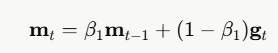
    $$\mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1 - \beta_1) \mathbf{g}_t$$

3.  Update biased second moment estimate (variance of gradients):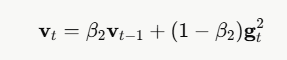
    $$\mathbf{v}_t = \beta_2 \mathbf{v}_{t-1} + (1 - \beta_2) \mathbf{g}_t^2$$

4.  Compute bias-corrected first moment estimate:
    $$\hat{\mathbf{m}}_t = \frac{\mathbf{m}_t}{1 - \beta_1^t}$$

5.  Compute bias-corrected second moment estimate:
    $$\hat{\mathbf{v}}_t = \frac{\mathbf{v}_t}{1 - \beta_2^t}$$

6.  Update parameters:
    $$\theta_{t+1} = \theta_t - \eta \frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon}$$

Where:
- $\theta_t$: Parameters at time step $t$
- $\mathbf{g}_t$: Gradients at time step $t$
- $\eta$: Learning rate
- $\beta_1, \beta_2$: Exponential decay rates for the moment estimates (typically 0.9 and 0.999 respectively)
- $\epsilon$: A small constant (e.g., $10^{-8}$) to prevent division by zero

Adam combines the advantages of both momentum and RMSprop, making it very effective for a wide range of deep learning tasks.

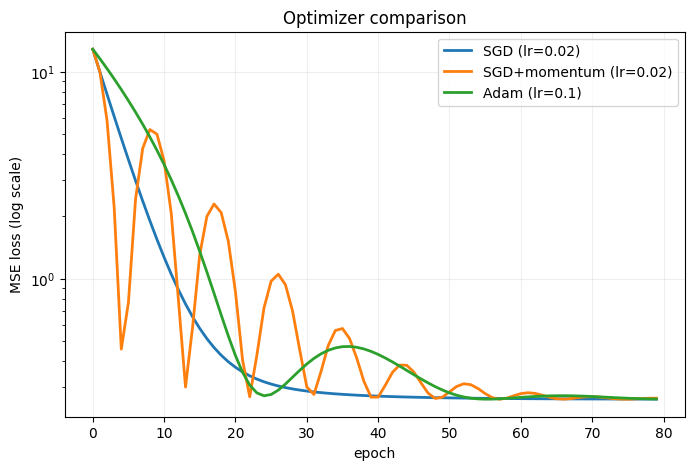

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

def make_data(n=100, seed=0):
    torch.manual_seed(seed)
    X = torch.linspace(-3, 3, n).reshape(-1, 1)
    y = 2 * X + 1 + 0.5 * torch.randn(X.shape)
    return X, y

def train_linear(optimizer_name, lr, epochs=80, seed=0):
    X, y = make_data(seed=seed)
    torch.manual_seed(seed)
    model = nn.Linear(1, 1)
    loss_fn = nn.MSELoss()
    if optimizer_name == "SGD":
        opt = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "SGD+momentum":
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "Adam":
        opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for _ in range(epochs):
        loss = loss_fn(model(X), y)
        opt.zero_grad(); loss.backward(); opt.step()
        history.append(loss.item())
    return history

plt.figure(figsize=(8, 5))
for name, lr in [("SGD", 0.02), ("SGD+momentum", 0.02), ("Adam", 0.1)]:
    plt.plot(train_linear(name, lr), label=f"{name} (lr={lr})", linewidth=2)
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("MSE loss (log scale)")
plt.title("Optimizer comparison"); plt.legend(); plt.grid(alpha=0.2); plt.show()

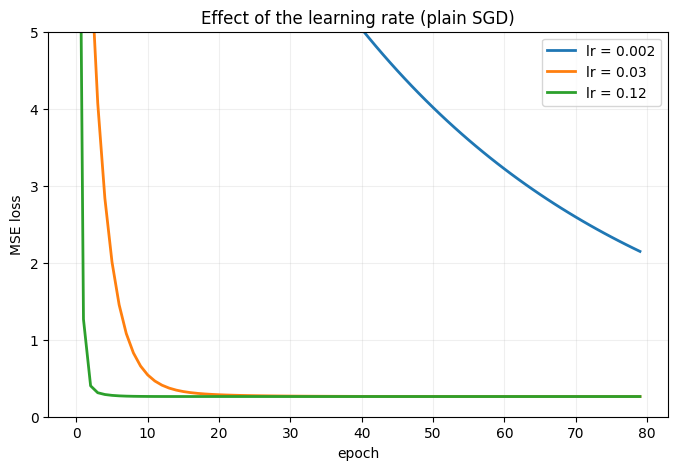

In [ ]:
# The learning rate: too small = slow, too large = unstable/diverges.
plt.figure(figsize=(8, 5))
for lr in [0.002, 0.03, 0.12]:
    hist = train_linear("SGD", lr, epochs=80)
    plt.plot(hist, label=f"lr = {lr}", linewidth=2)
plt.ylim(0, 5); plt.xlabel("epoch"); plt.ylabel("MSE loss")
plt.title("Effect of the learning rate (plain SGD)")
plt.legend(); plt.grid(alpha=0.2); plt.show()

**Takeaways**

- **SGD** follows the raw gradient; **momentum** accumulates a velocity term that
  smooths the path and speeds up convergence.
- **Adam** adapts a per-parameter step size and usually needs the least tuning —
  a sensible default for getting started.
- **Learning rate**: too small → painfully slow; too large → the loss oscillates
  or blows up (the `lr = 0.12` curve). Tuning it is usually the highest-leverage
  thing you can do. Tools like learning-rate schedulers (`torch.optim.lr_scheduler`)
  adjust it during training.

--------------

## 5. Overfitting and regularization

A model can memorize the training data instead of learning to generalize. We
diagnose this by watching **training loss vs. test (validation) loss**: when the
training loss keeps falling but the test loss flattens or rises, the model is
**overfitting**.

To make it obvious, we train on a deliberately **small subset** (2,000 images)
with a fairly large network. We then compare:

- a **plain** model, and
- a **regularized** model using **Dropout** + **weight decay** (L2).

*(This cell trains two models for a number of epochs — a few seconds on a GPU,
up to a minute or two on CPU.)*

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Small training subset so the model *can* overfit; held-out test set
train_subset = Subset(training_data, range(2000))
test_subset  = Subset(test_data,     range(2000))
tr_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
te_loader = DataLoader(test_subset,  batch_size=256)

def make_mlp(p_drop=0.0):
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28*28, 256), nn.ReLU(), nn.Dropout(p_drop),
        nn.Linear(256, 256),   nn.ReLU(), nn.Dropout(p_drop),
        nn.Linear(256, 10),
    )

def run(model, weight_decay=0.0, epochs=30):
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)

    def avg_loss(loader):
        model.eval(); total, n = 0.0, 0
        with torch.no_grad():
            for X, y in loader:
                X, y = X.to(device), y.to(device)
                total += loss_fn(model(X), y).item() * len(y); n += len(y)
        return total / n

    tr_hist, te_hist = [], []
    for _ in range(epochs):
        model.train()
        for X, y in tr_loader:
            X, y = X.to(device), y.to(device)
            loss = loss_fn(model(X), y)
            opt.zero_grad(); loss.backward(); opt.step()
        tr_hist.append(avg_loss(tr_loader))
        te_hist.append(avg_loss(te_loader))
    return tr_hist, te_hist

torch.manual_seed(0)
plain_tr, plain_te = run(make_mlp(p_drop=0.0), weight_decay=0.0)
torch.manual_seed(0)
reg_tr,   reg_te   = run(make_mlp(p_drop=0.3), weight_decay=1e-4)
print("Done. Final test loss  -> plain: "
      f"{plain_te[-1]:.3f} | regularized: {reg_te[-1]:.3f}")

Using device: cuda
Done. Final test loss  -> plain: 0.694 | regularized: 0.522


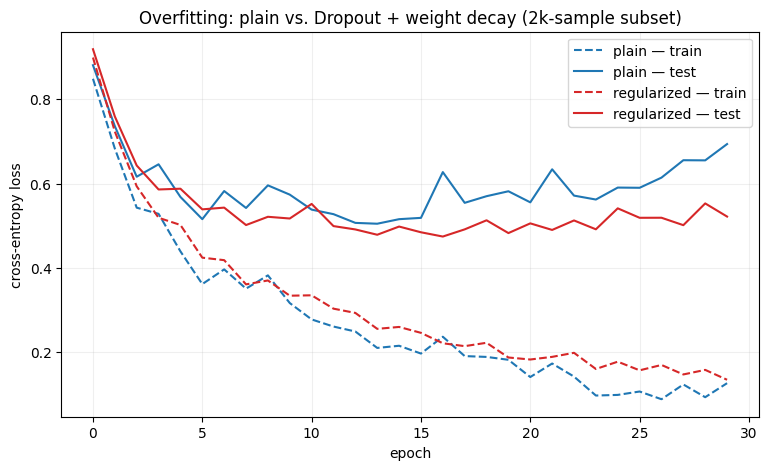

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(plain_tr, "--", color="tab:blue", label="plain — train")
plt.plot(plain_te, "-",  color="tab:blue", label="plain — test")
plt.plot(reg_tr,   "--", color="tab:red",  label="regularized — train")
plt.plot(reg_te,   "-",  color="tab:red",  label="regularized — test")
plt.xlabel("epoch"); plt.ylabel("cross-entropy loss")
plt.title("Overfitting: plain vs. Dropout + weight decay (2k-sample subset)")
plt.legend(); plt.grid(alpha=0.2); plt.show()

**Reading the curves**

- The **plain** model (blue) drives *train* loss toward zero while its *test*
  loss stalls or climbs — a widening gap is the signature of overfitting.
- The **regularized** model (red) keeps train and test loss closer together: it
  generalizes better even though its training loss is higher.

**Common ways to fight overfitting**

- **More / augmented data** — the most reliable fix.
- **Dropout** — randomly zeroes activations during training so the net can't rely
  on any single neuron (note it's active in `model.train()` and off in
  `model.eval()`).
- **Weight decay (L2)** — the `weight_decay` argument; penalizes large weights.
- **Batch normalization** (`nn.BatchNorm1d/2d`) — stabilizes and regularizes.
- **Early stopping** — stop when validation loss stops improving.

--------------

## Summary & exercises

Building on the fundamentals from Class 1, today we focused on **making training
work**:

- Wrote the **four-step training loop** (forward → loss → backward → update) by
  hand for linear regression.
- Saw why networks need **non-linear activations**, and compared ReLU, Tanh,
  Sigmoid, LeakyReLU, and GELU.
- Compared **optimizers** (SGD, SGD+momentum, Adam) and saw the dramatic effect
  of the **learning rate**.
- Diagnosed **overfitting** with train-vs-test curves and reduced it with
  **Dropout** and **weight decay**.

### Exercises

1. **Activations**: swap `nn.ReLU` for `nn.Tanh` (or `nn.GELU`) in `make_mlp`
   and compare the overfitting curves.
2. **Optimizer/LR**: retrain the FashionMNIST classifier with `Adam` at a few
   learning rates and plot test accuracy vs. learning rate.
3. **Regularization strength**: sweep `p_drop` over `{0.0, 0.2, 0.5}` and
   `weight_decay` over `{0, 1e-4, 1e-3}`; which combination generalizes best?
4. **Early stopping**: modify `run()` to keep the weights from the epoch with the
   lowest test loss.
5. **From scratch**: extend the manual linear-regression loop to fit a quadratic
   `y = w2·x² + w1·x + b`.

**Source: PyTorch Tutorials, extended for a second lecture on training dynamics.**